# Algorithm for this project.
1. START
2. IMPORT ALL necessary Libearies.
3. LOAD dataset.
4. Normalize the data.
5. devided data in to part Train_test_split.
6. Use from Randomforest Algorithm.
7. Prediction a result
8. Find accuracy,precision,confusionmatrix.
9. Drawing a graph for comparision accuracy between test_data and prediction_data
10. Use a function to take an email and predict ham or spam for you.
11. Make a GUI envorinoment
12. END

In [2]:
import pandas as pd  # type: ignore
from sklearn.naive_bayes import MultinomialNB# type: ignore
from sklearn.feature_extraction.text import CountVectorizer #type: ignore
from sklearn.metrics import accuracy_score,confusion_matrix # type: ignore
from sklearn.model_selection import train_test_split # type: ignore
import matplotlib.pyplot as plt # type: ignore
import tkinter as tk
import time as t

In [3]:
df = pd.read_csv(r"Email_spam_Dataset's.csv")

In [4]:
df

,Label,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [5]:
df.shape

(5572, 2)

In [6]:
df.head(10)

,Label,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


In [7]:
df.describe()

,Label,Message
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


In [8]:
df.nunique()

Label         2
Message    5169
dtype: int64

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Label    5572 non-null   object
 1   Message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [10]:
x = df['Message']
y = df['Label']


In [11]:
vectorizer = CountVectorizer()
x = vectorizer.fit_transform(x)
x

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 74169 stored elements and shape (5572, 8713)>

In [12]:
y

0        ham
1        ham
2       spam
3        ham
4        ham
        ... 
5567    spam
5568     ham
5569     ham
5570     ham
5571     ham
Name: Label, Length: 5572, dtype: object

In [13]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

In [14]:
x_train

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 59057 stored elements and shape (4457, 8713)>

In [15]:
naive_model = MultinomialNB(alpha=0.4)
naive_model.fit(x_train,y_train)

,alpha,0.4
,force_alpha,True
,fit_prior,True
,class_prior,None


In [16]:
naive_pred_test = naive_model.predict(x_test)
naive_pred_train = naive_model.predict(x_train)
naive_pred_test[:10],naive_pred_train[:10]

(array(['ham', 'ham', 'ham', 'ham', 'ham', 'ham', 'spam', 'ham', 'ham',
        'ham'], dtype='<U4'),
 array(['ham', 'ham', 'spam', 'ham', 'ham', 'ham', 'ham', 'ham', 'spam',
        'spam'], dtype='<U4'))

In [17]:
acc_test = accuracy_score(y_test,naive_pred_test)
acc_train = accuracy_score(y_train,naive_pred_train)
acc_test,acc_train

(0.9739910313901345, 0.9950639443571909)

In [18]:
print(f"Confusion Matrix for test \n{confusion_matrix(y_test,naive_pred_test)}")

Confusion Matrix for test 
[[943  18]
 [ 11 143]]


In [19]:
print(f"Confusion Matrix for train \n{confusion_matrix(y_train,naive_pred_train)}")

Confusion Matrix for train 
[[3850   14]
 [   8  585]]


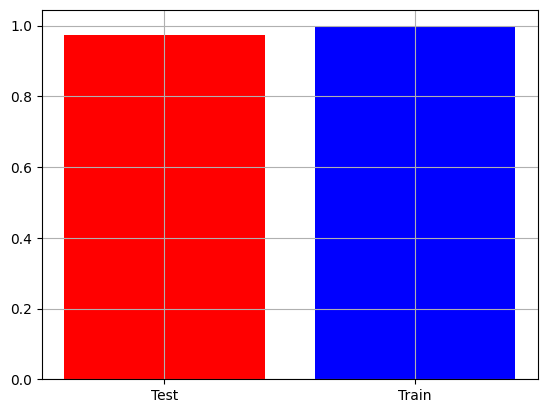

In [20]:
title = ["Test","Train"]
metrices = [acc_test,acc_train]
colors = ['red','blue']
plt.bar(title,metrices,color = colors)
plt.grid()
plt.show()

In [ ]:
# def prediction(text):
#     new_pred = naive_model.transform(text)
#     new_pred_ = naive_model.predict(new_pred_)
#     return new_pred_

In [26]:
root = tk.Tk()
root.title("The Spam and non-spam email")
root.geometry("600x550")

title_label = tk.Label(root,text = '`EMR` Spam and non-spam emails',font = ("Arial",18,"bold"))
title_label.pack(pady = 20)

Email_label = tk.Label(root,text = "Enter the Email ")
Email_entry = tk.Entry(root,width=30)
Email_label.pack(pady = 5)

def predict_result():
    textEmail = input(Email_entry.get())
    new_data = vectorizer.fit_transform(textEmail)
    prediction = naive_model.predict(new_data)
    result_label.config(text = f"Prediction the result{prediction[0]}")
predict_button = tk.Button(root,text = "Predict a reuslt",command = predict_result, bg = 'gray', fg = 'blue',font = (12,12))    


predict_button.pack(pady = 20)
result_label = tk.Label(root,text = "Prediction will appear here ... ", font = ("Arial",12))
result_label.pack(pady = 10)
root.mainloop()

Exception in Tkinter callback
Traceback (most recent call last):
  File "c:\Users\Musa\AppData\Local\Programs\Python\Python313\Lib\tkinter\__init__.py", line 2074, in __call__
    return self.func(*args)
           ~~~~~~~~~^^^^^^^
  File "C:\Users\Musa\AppData\Local\Temp\ipykernel_9624\357592225.py", line 14, in predict_result
    new_data = vectorizer.fit_transform(textEmail)
  File "c:\Users\Musa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\Musa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\feature_extraction\text.py", line 1355, in fit_transform
    raise ValueError(
        "Iterable over raw text documents expected, string object received."
    )
ValueError: Iterable over raw text documents expected, string object received.
